# Analysis of variance (ANOVA)

## Libraries and settings

In [1]:
# Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Settings for seaborn
sns.set_theme(style="ticks", palette="pastel")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Get current working directory
print('Current working directory:', os.getcwd())

Current working directory: /Users/adisaljusi/repos/data_analytics/Week_06


## Read example data (used car data)

In [2]:
# Read data
df = pd.read_excel('t-tests_and_ANOVA.xlsx', sheet_name='anova_data')

# Show categories of 'Make'
print(df['Make'].value_counts())

# Show header
df.head()

Make
VW      20
BMW     20
Fiat    20
Name: count, dtype: int64


,Make,Price
0,VW,29000
1,VW,38000
2,VW,33000
3,VW,64000
4,VW,52000


## Create pivot table of mean price per make

In [3]:
# Create pivot table
table = pd.pivot_table(df, 
                       values='Price',
                       columns=['Make'], 
                       aggfunc=np.mean)
print(table)

Make       BMW     Fiat       VW
Price  54000.0  34000.0  41950.0


## Create grouped boxplot (groups = make, values = prices)

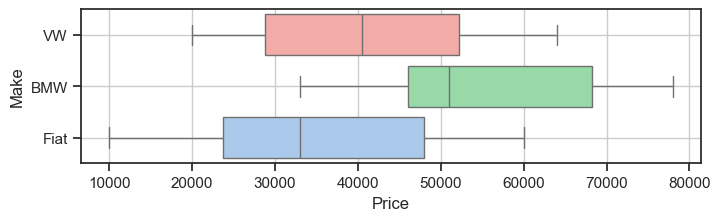

In [4]:
# Plot boxplot with groups
plt.figure(figsize=(8,2))
ax = sns.boxplot(x="Price",
                 y="Make",
                 palette=['r', 'g', 'b'],
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## Analysis of variance (ANOVA)

In [5]:
# Create subsets (groups)
vw = df.loc[df['Make'] == 'VW']
bmw = df.loc[df['Make'] == 'BMW']
fiat = df.loc[df['Make'] == 'Fiat']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(vw['Price'],
                                fiat['Price'], 
                                bmw['Price'])

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 9.791 p-value 0.0002


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the used car prices of VW, BMW and Fiat differ. Note that, from the ANOVA, it is not clear which groups show differences of prices. For this a post-hoc test could be used (not part of the exercises).</p>

## Importing apartment data

In [6]:
# Read the data to a pandas data frame
df = pd.read_csv('apartments_data_enriched_cleaned.csv', 
                 sep=';', 
                 encoding='utf-8')[['web-scraper-order',
                                    'address_raw',
                                    'lat',
                                    'lon',
                                    'bfs_number',
                                    'bfs_name',
                                    'rooms', 
                                    'area', 
                                    'luxurious', 
                                    'price', 
                                    'price_per_m2',
                                    'pop_dens',
                                    'frg_pct',
                                    'mean_taxable_income',
                                    'dist_supermarket']]

# Get number of rows and columns
print(df.shape)

# Show first records
df.head(5)

(774, 15)


,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop_dens,frg_pct,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49,0,1441,29.41,1221.272366,24.841283,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111,0,2600,23.42,1221.272366,24.841283,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58,0,1490,25.69,1221.272366,24.841283,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",47.259834,8.851705,118,Rüti (ZH),4.0,118,0,3240,27.46,1221.272366,24.841283,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",47.266113,8.866872,118,Rüti (ZH),3.0,66,0,1450,21.97,1221.272366,24.841283,65362.04268,974.844209


## Create pivot table with mean price_per_m2 per room size

In [7]:
# Using pivot_table to reshape the data and calculate means 
pd.pivot_table(df[['rooms', 'price_per_m2']],
               index=['rooms'],
               values=['price_per_m2'],
               aggfunc=[np.mean, 'count'])

,mean,count
,price_per_m2,price_per_m2
rooms,,
1.0,47.140400,50
1.5,59.417576,33
2.0,40.757105,38
2.5,37.391631,141
3.0,28.677955,44
3.5,29.942956,203
4.0,29.646429,28
4.5,26.493436,163


## Create grouped boxplot (groups = rooms, values = prices_per_m2)

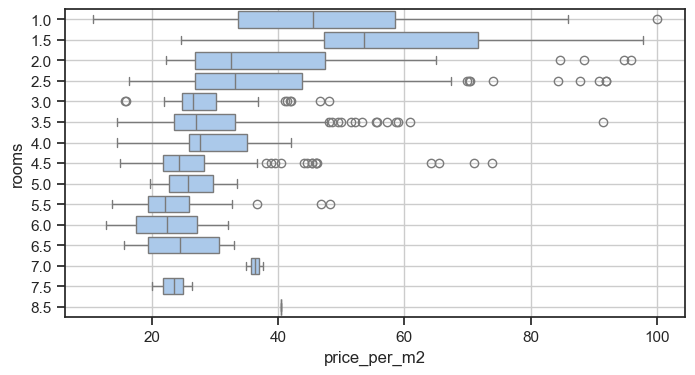

In [8]:
# Plot boxplot with groups
plt.figure(figsize=(8,4))
ax = sns.boxplot(x="price_per_m2",
                 y="rooms",
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## ANOVA to compare the price_per_m2 per number of rooms (= groups)

In [9]:
# Create subsets (groups)
r2_5 = df.loc[df['rooms'] == 2.5]['price_per_m2']
r3_5 = df.loc[df['rooms'] == 3.5]['price_per_m2']
r4_5 = df.loc[df['rooms'] == 4.5]['price_per_m2']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(r2_5, r3_5, r4_5)

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 34.26 p-value 0.0


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the price per m2 differ between apartments with 2.5, 3.5 and 4.5 rooms. Note that, from the ANOVA, it is not clear which groups show price differences. For this a post-hoc test could be used (not part of the exercises).</p>

## Task b) Create three subsets based on population density

In [10]:

low_pop_dens = df.loc[df['pop_dens'] <= 600]
moderate_pop_dens = df.loc[(df['pop_dens'] > 600) & (df['pop_dens'] <= 1500)]
high_pop_dens = df.loc[df['pop_dens'] > 1500]


print(f'Low population density (pop_dens <= 600): {len(low_pop_dens)} apartments')
print(f'Moderate population density (600 < pop_dens <= 1500): {len(moderate_pop_dens)} apartments')
print(f'High population density (pop_dens > 1500): {len(high_pop_dens)} apartments')
print(f'\nTotal apartments: {len(low_pop_dens) + len(moderate_pop_dens) + len(high_pop_dens)}')

Low population density (pop_dens <= 600): 105 apartments
Moderate population density (600 < pop_dens <= 1500): 217 apartments
High population density (pop_dens > 1500): 452 apartments

Total apartments: 774


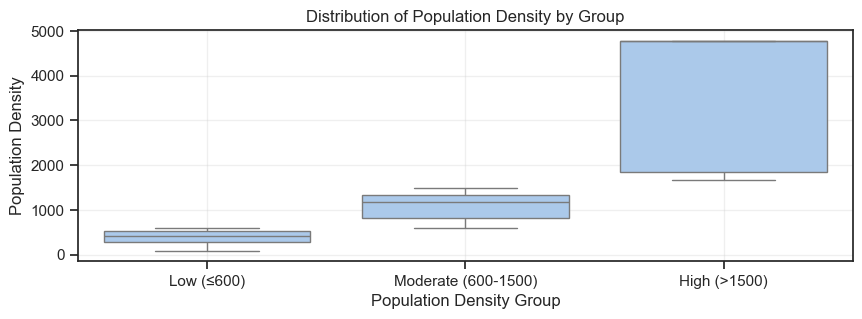

In [11]:
df_copy = df.copy()
df_copy['pop_dens_group'] = pd.cut(df_copy['pop_dens'], 
                                     bins=[0, 600, 1500, float('inf')],
                                     labels=['Low (≤600)', 'Moderate (600-1500)', 'High (>1500)'])

plt.figure(figsize=(10, 3))
sns.boxplot(x='pop_dens_group', y='pop_dens', data=df_copy)
plt.title('Distribution of Population Density by Group')
plt.xlabel('Population Density Group')
plt.ylabel('Population Density')
plt.grid(True, alpha=0.3)
plt.show()

## Task c) One-way ANOVA: Price per m2 across population density groups

In [12]:

print(f"Low pop. density n={len(low_pop_dens)}: Mean = {low_pop_dens['price_per_m2'].mean():.2f}, SD = {low_pop_dens['price_per_m2'].std():.2f}")
print(f"Moderate pop. density n={len(moderate_pop_dens)}: Mean = {moderate_pop_dens['price_per_m2'].mean():.2f}, SD = {moderate_pop_dens['price_per_m2'].std():.2f}")
print(f"High pop. density n={len(high_pop_dens)}: Mean = {high_pop_dens['price_per_m2'].mean():.2f}, SD = {high_pop_dens['price_per_m2'].std():.2f}")

Low pop. density n=105: Mean = 23.57, SD = 5.45
Moderate pop. density n=217: Mean = 25.98, SD = 6.94
High pop. density n=452: Mean = 38.32, SD = 16.65


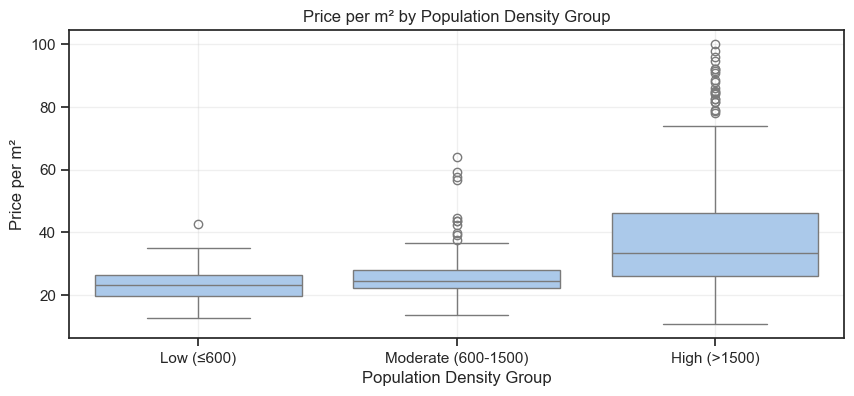

In [13]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='pop_dens_group', y='price_per_m2', data=df_copy)
plt.title('Price per m² by Population Density Group')
plt.xlabel('Population Density Group')
plt.ylabel('Price per m²')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
fvalue_price, pvalue_price = stats.f_oneway(low_pop_dens['price_per_m2'],
                                             moderate_pop_dens['price_per_m2'],
                                             high_pop_dens['price_per_m2'])

print('One-way ANOVA for Price per m²:')
print(f'F-statistic: {fvalue_price:.55f}')
print(f'p-value: {pvalue_price:.55f}')

One-way ANOVA for Price per m²:
F-statistic: 91.2722645654102819889885722659528255462646484375000000000
p-value: 0.0000000000000000000000000000000000026516452554352655075


**Interpretation:**

The p-value is < 0.05, therefore, we reject the null hypothesis. This indicates that there is statistically significant evidence that the mean price per m^2 differs across at least one of the population density groups (low, moderate, high).

## Task d) One-way ANOVA: Area across population density groups

**Hypotheses:**
- **Null hypothesis (H₀):** The mean area of rental apartments is equal across all three population density groups (low, moderate, high).
- **Alternative hypothesis (H₁):** At least one population density group has a different mean apartment area compared to the others.
- **Significance level:** α = 0.05

In [15]:
print(f"Low pop. density n={len(low_pop_dens)}: Mean = {low_pop_dens['area'].mean():.2f}, SD = {low_pop_dens['area'].std():.2f}")
print(f"Moderate pop. density n={len(moderate_pop_dens)}: Mean = {moderate_pop_dens['area'].mean():.2f}, SD = {moderate_pop_dens['area'].std():.2f}")
print(f"High pop. density n={len(high_pop_dens)}: Mean = {high_pop_dens['area'].mean():.2f}, SD = {high_pop_dens['area'].std():.2f}")

Low pop. density n=105: Mean = 112.78, SD = 42.63
Moderate pop. density n=217: Mean = 91.69, SD = 35.32
High pop. density n=452: Mean = 82.01, SD = 38.41


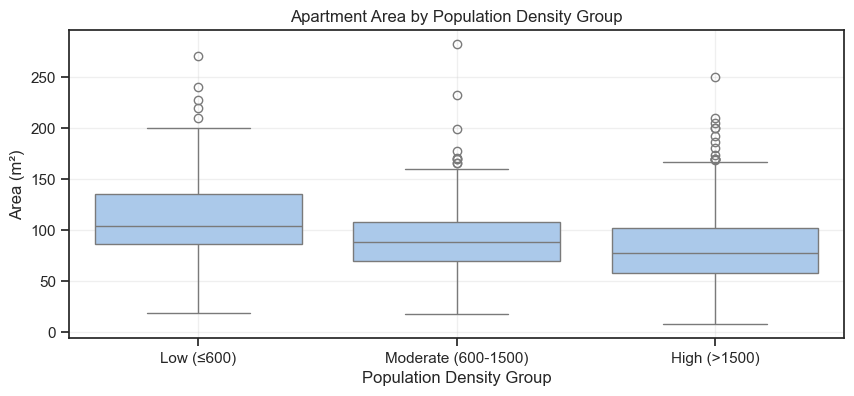

In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='pop_dens_group', y='area', data=df_copy)
plt.title('Apartment Area by Population Density Group')
plt.xlabel('Population Density Group')
plt.ylabel('Area (m²)')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
fvalue_area, pvalue_area = stats.f_oneway(low_pop_dens['area'],
                                          moderate_pop_dens['area'],
                                          high_pop_dens['area'])

print('One-way ANOVA for Apartment Area:')
print(f'F-statistic: {fvalue_area:.55f}')
print(f'p-value: {pvalue_area:.55f}')

One-way ANOVA for Apartment Area:
F-statistic: 28.4775238322566153215120721142739057540893554687500000000
p-value: 0.0000000000011691156081837437575178602007873717707683858


**Interpretation:**

The p-value is < 0.05, therefore, we reject the null hypothesis. This indicates that there is statistically significant evidence that the mean apartment area differs across at least one of the population density groups. This suggests that population density has a significant effect on the size of rental apartments.

## Task e) One-way ANOVA: Number of rooms across population density groups

In [18]:
# Descriptive statistics for rooms by population density group
print('Descriptive statistics for number of rooms:\n')
print(f"Low pop. density (n={len(low_pop_dens)}): Mean = {low_pop_dens['rooms'].mean():.2f}, SD = {low_pop_dens['rooms'].std():.2f}")
print(f"Moderate pop. density (n={len(moderate_pop_dens)}): Mean = {moderate_pop_dens['rooms'].mean():.2f}, SD = {moderate_pop_dens['rooms'].std():.2f}")
print(f"High pop. density (n={len(high_pop_dens)}): Mean = {high_pop_dens['rooms'].mean():.2f}, SD = {high_pop_dens['rooms'].std():.2f}")

Descriptive statistics for number of rooms:

Low pop. density (n=105): Mean = 4.21, SD = 1.18
Moderate pop. density (n=217): Mean = 3.67, SD = 1.10
High pop. density (n=452): Mean = 3.11, SD = 1.28


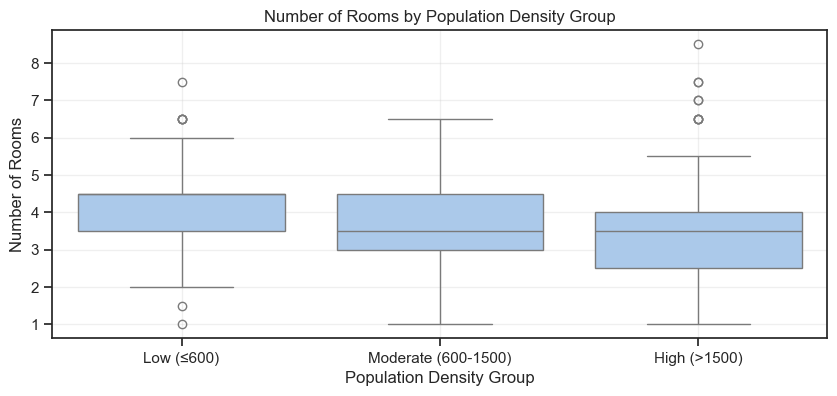

In [19]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='pop_dens_group', y='rooms', data=df_copy)
plt.title('Number of Rooms by Population Density Group')
plt.xlabel('Population Density Group')
plt.ylabel('Number of Rooms')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
fvalue_rooms, pvalue_rooms = stats.f_oneway(low_pop_dens['rooms'],
                                            moderate_pop_dens['rooms'],
                                            high_pop_dens['rooms'])

print('One-way ANOVA for Number of Rooms:')
print(f'F-statistic: {fvalue_rooms:.55f}')
print(f'p-value: {pvalue_rooms:.55f}')

One-way ANOVA for Number of Rooms:
F-statistic: 41.0434303295532316724347765557467937469482421875000000000
p-value: 0.0000000000000000115229512528086812458186729758226782794


**Interpretation:**

The p-value is < 0.05. Therefore, we reject the null hypothesis. This indicates that there is statistically significant evidence that the mean number of rooms differs across at least one of the population density groups. This suggests that population density has a significant effect on the number of rooms in rental apartments.

## Summary of ANOVA Results

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [21]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.0.0
Datetime: 2025-10-28 13:15:23
Python Version: 3.11.13
-----------------------------------
